In [1]:
import pandas as pd 
from datasets import load_dataset, load_from_disk
import pyarrow.parquet as pq  
import time
import numpy as np

/gpfs/data/brandeslab/User/as12267/.conda/envs/huggingface_bert_cu126/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
parquet_path = "/gpfs/data/brandeslab/Data/uniref/uniref90_clusters.parquet"
table = pq.read_table(parquet_path)
clusters = table.to_pylist()
print(f"Loaded {len(clusters)} clusters into memory.")

In [ ]:
import pyarrow.parquet as pq
import random

class CachedRowGroupClusterSampler:
    def __init__(self, parquet_path):
        self.pf = pq.ParquetFile(parquet_path)
        self.num_row_groups = self.pf.num_row_groups
        self.row_group_cache = []
        self.current_rg_index = None

    def sample_cluster(self):
        # If cache is empty, load a new row group
        if not self.row_group_cache:
            # Choose a random row group
            rg_idx = random.randint(0, self.num_row_groups - 1)
            table = self.pf.read_row_group(rg_idx)
            rows = table.to_pylist()  # 1840 rows typically
            random.shuffle(rows)  # Shuffle to maintain randomness
            self.row_group_cache.extend(rows)
            self.current_rg_index = rg_idx

        # Pop one sample from cache
        row = self.row_group_cache.pop()
        return {
            "cluster_id": row["cluster_id"],
            "representative_id": row["representative_id"],
            "members": row["members"],
        }


In [ ]:
class RandomClusterSampler:
    def __init__(self, parquet_path):
        self.path = parquet_path
        
        # Read metadata once
        self.meta = pq.read_metadata(parquet_path)
        self.num_row_groups = self.meta.num_row_groups 
        
        # Open ParquetFile once 
        self.pf = pq.ParquetFile(parquet_path)

    def sample_clusters(self):
        # randomly select a row group (multiple clusters per row group)
        rg = np.random.randint(0, self.num_row_groups)

        # read only that row group 
        table = self.pf.read_row_group(rg)
        n = table.num_rows

        # Pick random row (cluster) from the row group
        cluster_idx = np.random.randint(0, n)
        row = table.slice(cluster_idx, 1)

        cluster_id = row["cluster_id"][0].as_py()
        rep_id      = row["representative_id"][0].as_py()
        members     = row["members"][0].as_py()

        return {
            "cluster_id": cluster_id,
            "representative_id": rep_id,
            "members": members
        }

In [ ]:
class InMemoryClusterSampler:
    def __init__(self, parquet_path):
        print(f"Loading Parquet file into memory (Arrow table): {parquet_path}...")
        self.table = pq.read_table(parquet_path)  
        self.num_rows = self.table.num_rows
        print(f"Loaded Arrow table with {self.num_rows} clusters.")

    def sample_cluster(self):
        idx = random.randint(0, self.num_rows - 1)
        row = {k: self.table[k][idx].as_py() for k in self.table.column_names}
        return {
            "cluster_id": row["cluster_id"],
            "representative_id": row["representative_id"],
            "members": row["members"],
        }

In [ ]:
parquet_path = "/gpfs/data/brandeslab/Data/uniref/uniref90_clusters.parquet"
sampeler1_start_time = time.time()
sampler1 = CachedRowGroupClusterSampler(parquet_path)
# Example usage
sampler1_samples = []
for i in range(129):
    sample = sampler1.sample_cluster()
    sampler1_samples.append(sample)
print(len(sampler1_samples))  # Print a sampled cluster
sampeler1_end_time = time.time()
print(f"Sampler1 Time taken: {sampeler1_end_time - sampeler1_start_time} seconds")

129
Sampler1 Time taken: 0.8135685920715332 seconds


In [ ]:
parquet_path = "/gpfs/data/brandeslab/Data/uniref/uniref90_clusters.parquet"
sampeler2_start_time = time.time()
sampler2 = RandomClusterSampler(parquet_path)
# Example usage
sampler2_samples = []
for i in range(129):
    sample = sampler2.sample_clusters()
    sampler2_samples.append(sample)
print(len(sampler2_samples))  # Print a sampled cluster
sampeler2_end_time = time.time()
print(f"Sampler1 Time taken: {sampeler2_end_time - sampeler2_start_time} seconds")

129
Sampler1 Time taken: 5.8889000415802 seconds


In [ ]:
meta = load_dataset("parquet", 
                    data_files="/gpfs/data/brandeslab/Data/uniref/uniref90_clusters.parquet")["train"]

Generating train split: 184146434 examples [00:20, 8911737.66 examples/s] 


In [ ]:
ds = load_dataset(
    "parquet",
    data_files="/gpfs/data/brandeslab/Data/uniref/uniref90_clusters.parquet",
    split="train",
    streaming=True
)


In [ ]:
stream = load_dataset(
    "parquet",
    data_files="/gpfs/data/brandeslab/Data/uniref/uniref90_clusters.parquet",
    streaming=True
)

In [ ]:
from datasets import Dataset

ds = Dataset.from_parquet("/gpfs/data/brandeslab/Data/uniref/uniref90_clusters.parquet")

Generating train split: 184146434 examples [00:18, 9966633.86 examples/s] 


In [ ]:
from datasets import load_dataset

ds = load_dataset(
    "parquet",
    data_files="/gpfs/data/brandeslab/Data/uniref/uniref90_clusters.parquet",
    split="train",      # required if not streaming
    streaming=False     # or just omit this arg
)

print(ds)
print(ds.features)


Dataset({
    features: ['cluster_id', 'representative_id', 'member_count_xml_file', 'member_count', 'members'],
    num_rows: 184146434
})
{'cluster_id': Value(dtype='string', id=None), 'representative_id': Value(dtype='string', id=None), 'member_count_xml_file': Value(dtype='int32', id=None), 'member_count': Value(dtype='int32', id=None), 'members': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None)}


In [ ]:
import pyarrow.parquet as pq
from datasets import Dataset

table = pq.read_table("/gpfs/data/brandeslab/Data/uniref/uniref90_clusters.parquet")
ds = Dataset(table)
print(ds)

Dataset({
    features: ['cluster_id', 'representative_id', 'member_count_xml_file', 'member_count', 'members'],
    num_rows: 184146434
})


In [ ]:
import pyarrow.parquet as pq

table = pq.read_table("/gpfs/data/brandeslab/Data/uniref/uniref90_clusters.parquet")
table

pyarrow.Table
cluster_id: string
representative_id: string
member_count_xml_file: int32
member_count: int32
members: list<element: string>
  child 0, element: string
----
cluster_id: [["UniRef90_UPI002E2621C6","UniRef90_UPI00358F51CD","UniRef90_UPI00398E31D8","UniRef90_A0A5A9P0L4","UniRef90_A0ABD1JBH0",...,"UniRef90_UPI00225B580A","UniRef90_UPI00254460F6","UniRef90_UPI002796F535","UniRef90_UPI002896634E","UniRef90_UPI003D7BF59D"],["UniRef90_UPI00222E980F","UniRef90_UPI0024785306","UniRef90_UPI0035A280ED","UniRef90_UPI001B351495","UniRef90_UPI00222EC2CE",...,"UniRef90_UPI00248289A7","UniRef90_UPI0012FEA33D","UniRef90_A0A8C5NYK4","UniRef90_UPI0025ADAEBD","UniRef90_UPI003BF9D085"],...,["UniRef90_A0A3M7PZG0","UniRef90_Q9BM67","UniRef90_Q9BM66","UniRef90_E9BBM2","UniRef90_Q9BLZ4",...,"UniRef90_A0A0T5Z569","UniRef90_D4J9Q7","UniRef90_A0A6A7YBE0","UniRef90_A0A0T5Z260","UniRef90_A0A5C6IVY6"],["UniRef90_Q725V0","UniRef90_A0A4R4SIP9","UniRef90_A0ABW1B1Z7","UniRef90_A0A943LZD8","UniRef90_A0ABV6HH

In [ ]:
pq.read_metadata("/gpfs/data/brandeslab/Data/uniref/uniref90_clusters.parquet").num_rows

184146434

In [ ]:
table.schema

cluster_id: string
representative_id: string
member_count_xml_file: int32
member_count: int32
members: list<element: string>
  child 0, element: string

In [ ]:
import pandas as pd
df = pd.read_csv("/gpfs/data/brandeslab/Data/uniref/uniref90_cluster_members.tsv", sep="\t", nrows=100)
df

,ClusterID,RepresentativeID,member_count_xml_file,member_count,MemberIDs
0,UniRef90_UPI002E2621C6,UPI002E2621C6,1,1,NaN
1,UniRef90_UPI00358F51CD,UPI00358F51CD,1,1,NaN
2,UniRef90_UPI00398E31D8,UPI00398E31D8,1,1,NaN
3,UniRef90_A0A5A9P0L4,A0A5A9P0L4_9TELE,1,1,NaN
4,UniRef90_A0ABD1JBH0,A0ABD1JBH0_9TELE,1,1,NaN
...,...,...,...,...,...
95,UniRef90_A0A6P8RG45,A0A6P8RG45_GEOSA,1,1,NaN
96,UniRef90_UPI003D69693D,UPI003D69693D,1,1,NaN
97,UniRef90_UPI003EBDD6D2,UPI003EBDD6D2,3,3,"UPI003EBC14C6,UPI003EB9A168"
98,UniRef90_A0A1V4K6M4,A0A1V4K6M4_PATFA,562,562,"A0A7K4RU14_COLPI,A0A7L4G2H3_9COLU,A0A094KAD8_A..."


In [ ]:
df.iloc[97]

ClusterID                     UniRef90_UPI003EBDD6D2
RepresentativeID                       UPI003EBDD6D2
member_count_xml_file                              3
member_count                                       3
MemberIDs                UPI003EBC14C6,UPI003EB9A168
Name: 97, dtype: object

In [ ]:
!pip install parasail

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [ ]:
import parasail

In [ ]:
import sys
!{sys.executable} -m pip install parasail

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [ ]:
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Split
from transformers import PreTrainedTokenizerFast

# Define vocabulary: ONLY standard 20 amino acids
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")  # Standard 20 only
special_tokens = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]", "-"]

# Build vocabulary
vocab = {token: i for i, token in enumerate(special_tokens + amino_acids)}

print(f"Vocab: {vocab}")
print(f"'-' ID: {vocab['-']}")

# Create tokenizer
tokenizer = Tokenizer(WordLevel(vocab=vocab, unk_token="[UNK]"))
tokenizer.pre_tokenizer = Split(pattern="", behavior="isolated")

# Wrap it
hf_tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer,
    unk_token="[UNK]",
    pad_token="[PAD]",
    cls_token="[CLS]",
    sep_token="[SEP]",
    mask_token="[MASK]"
)

# Test
print("\nTests:")
print("'-' converts to:", hf_tokenizer.convert_tokens_to_ids("-"))
print("Tokenization of 'ACD-GH':", hf_tokenizer("ACD-GH"))
print("Decoding:", hf_tokenizer.decode([6, 7, 8, 5, 11, 12]))
print("Vocab size:", len(hf_tokenizer))

# hf_tokenizer.save_pretrained("phylo_char_tokenizer")

Vocab: {'[PAD]': 0, '[UNK]': 1, '[CLS]': 2, '[SEP]': 3, '[MASK]': 4, '-': 5, 'A': 6, 'C': 7, 'D': 8, 'E': 9, 'F': 10, 'G': 11, 'H': 12, 'I': 13, 'K': 14, 'L': 15, 'M': 16, 'N': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'V': 23, 'W': 24, 'Y': 25}
'-' ID: 5

Tests:
'-' converts to: 5
Tokenization of 'ACD-GH': {'input_ids': [6, 7, 8, 5, 11, 12], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}
Decoding: A C D - G H
Vocab size: 26


In [ ]:
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Split
from transformers import PreTrainedTokenizerFast

# Define vocabulary: ONLY standard 20 amino acids
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")  # Standard 20 only
special_tokens = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]", "[GAP]", "-"]


# Build vocabulary
vocab = {token: i for i, token in enumerate(special_tokens + amino_acids)}

print(f"Vocab: {vocab}")
print(f"'-' ID: {vocab['-']}")
print(f"[GAP] ID: {vocab['[GAP]']}")
print(f"[MASK] ID: {vocab['[MASK]']}")

# Create tokenizer
tokenizer = Tokenizer(WordLevel(vocab=vocab, unk_token="[UNK]"))
tokenizer.pre_tokenizer = Split(pattern="", behavior="isolated")

# Wrap it
hf_tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer,
    unk_token="[UNK]",
    pad_token="[PAD]",
    cls_token="[CLS]",
    sep_token="[SEP]",
    mask_token="[MASK]",
    additional_special_tokens=["[GAP]"]  # 👈 Register [GAP] as special
)

# Test
print("\nTests:")
print("'-' converts to:", hf_tokenizer.convert_tokens_to_ids("-"))
print("[GAP] converts to:", hf_tokenizer.convert_tokens_to_ids("[GAP]"))
print("[MASK] converts to:", hf_tokenizer.convert_tokens_to_ids("[MASK]"))
print("\n")
print("Tokenization of 'ACD-GH':", hf_tokenizer("ACD-GH", add_special_tokens=False))
print("Tokenization of  'ACD[GAP]GH':", hf_tokenizer("ACD[GAP]GH", add_special_tokens=False))
# print("Decoding:", hf_tokenizer.decode([6, 7, 8, 5, 11, 12]))
print("Vocab size:", len(hf_tokenizer))

hf_tokenizer.save_pretrained("phylo_char_tokenizer_updated")

Vocab: {'[PAD]': 0, '[UNK]': 1, '[CLS]': 2, '[SEP]': 3, '[MASK]': 4, '[GAP]': 5, '-': 6, 'A': 7, 'C': 8, 'D': 9, 'E': 10, 'F': 11, 'G': 12, 'H': 13, 'I': 14, 'K': 15, 'L': 16, 'M': 17, 'N': 18, 'P': 19, 'Q': 20, 'R': 21, 'S': 22, 'T': 23, 'V': 24, 'W': 25, 'Y': 26}
'-' ID: 6
[GAP] ID: 5
[MASK] ID: 4

Tests:
'-' converts to: 6
[GAP] converts to: 5
[MASK] converts to: 4


Tokenization of 'ACD-GH': {'input_ids': [7, 8, 9, 6, 12, 13], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}
Tokenization of  'ACD[GAP]GH': {'input_ids': [7, 8, 9, 5, 12, 13], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}
Vocab size: 27


('phylo_char_tokenizer_updated/tokenizer_config.json',
 'phylo_char_tokenizer_updated/special_tokens_map.json',
 'phylo_char_tokenizer_updated/tokenizer.json')

In [ ]:
import parasail 

In [ ]:
import sys
print(sys.executable)

/gpfs/home/as12267/.conda/envs/huggingface_bert/bin/python


In [ ]:
import sys
[p for p in sys.path if "conda" in p]

['/gpfs/home/as12267/.conda/envs/huggingface_bert/lib/python310.zip',
 '/gpfs/home/as12267/.conda/envs/huggingface_bert/lib/python3.10',
 '/gpfs/home/as12267/.conda/envs/huggingface_bert/lib/python3.10/lib-dynload',
 '/gpfs/home/as12267/.conda/envs/huggingface_bert/lib/python3.10/site-packages']

In [ ]:
import parasail
result = parasail.nw_trace_scan_16("AAAA", "AAAA", 5, 1, parasail.blosum62)

print(dir(result))

['__class__', '__del__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_as_parameter_', '_cigar', '_traceback', '_traceback_args', 'cigar', 'end_query', 'end_ref', 'get_cigar', 'get_traceback', 'len_query', 'len_ref', 'length', 'length_col', 'length_row', 'length_table', 'matches', 'matches_col', 'matches_row', 'matches_table', 'matrix', 'pointer', 'query', 'ref', 'saturated', 'score', 'score_col', 'score_row', 'score_table', 'similar', 'similar_col', 'similar_row', 'similar_table', 'traceback']


In [ ]:
import parasail

matrix = parasail.blosum62

def align_pair(seq1, seq2):
    # global Needleman–Wunsch alignment with traceback
    result = parasail.nw_trace_scan_16(seq1, seq2, 10, 1, matrix)

    # Extract the traceback object
    tb = result.traceback

    # Get aligned sequences
    # a1 = tb.query.replace("-", "<GAP>")
    # a2 = tb.ref.replace("-", "<GAP>")
    a1 = tb.query
    a2 = tb.ref

    return a1, a2

# Test sequences
seq1 = "MKTAYIAKQRQISFVKSHFSRQLEERLGLIE"
seq2 = "MKTVYIAKRRQISFLKSHFSRQLDDRLGLIE"

a1, a2 = align_pair(seq1, seq2)

print("Seq1 Aligned:", a1)
print("Seq2 Aligned:", a2)


Seq1 Aligned: MKTAYIAKQRQISFVKSHFSRQLEERLGLIE
Seq2 Aligned: MKTVYIAKRRQISFLKSHFSRQLDDRLGLIE


In [ ]:
from gLM.sequences import align_pair
seq1 = "MKTAYIAKQRQISFVKSHFS"
seq2 = "MKTA---QRQISFVKSHFSSS"

a1, a2 = align_pair(seq1, seq2)

print("Seq1 Aligned:", a1)
print("Seq2 Aligned:", a2)

print(f"Seq1 Aligned with [GAP]:", a1.replace("-", "[GAP]"))
print(f"Seq2 Aligned with [GAP]:", a2.replace("-", "[GAP]"))

Seq1 Aligned: MKTAYIAKQRQISFVKSHF--S
Seq2 Aligned: MKTA----QRQISFVKSHFSSS
Seq1 Aligned with [GAP]: MKTAYIAKQRQISFVKSHF[GAP][GAP]S
Seq2 Aligned with [GAP]: MKTA[GAP][GAP][GAP][GAP]QRQISFVKSHFSSS


In [ ]:
from transformers import (
    PreTrainedTokenizerFast,
)

class PhyloTokenizerLoader:
    def __init__(self, tokenizer_path):
        self.tokenizer = PreTrainedTokenizerFast.from_pretrained(tokenizer_path)
    
    def encode(self, aligned_seq1, aligned_seq2):
        inputs = self.tokenizer(
            aligned_seq2,
            add_special_tokens=False
        )
        labels = self.tokenizer(
            aligned_seq1,
            add_special_tokens=False
        )
        return{
            "input_ids": inputs["input_ids"],
            "labels": labels["input_ids"], 
            "attention_mask": inputs["attention_mask"]
        }
    
    def __call__(self, *args, **kwargs):
        return self.tokenizer(*args, **kwargs)

# Set breakpoint inside encode() method
# Then run this:
phylo_tokenizer = PhyloTokenizerLoader("phylo_char_tokenizer")

# When you call encode, debugger will pause at your breakpoint
result = phylo_tokenizer.encode("ATCG", "ATCG")

In [ ]:
result

{'input_ids': [6, 22, 7, 11],
 'labels': [6, 22, 7, 11],
 'attention_mask': [1, 1, 1, 1]}

In [ ]:
from gLM.dataset import UniRefClusterIterableDataset
from gLM.tokenizers import PhyloTokenizerLoader


In [ ]:
tokenizer = PhyloTokenizerLoader("./phylo_char_tokenizer").load()


In [ ]:
ds = UniRefClusterIterableDataset(
    parquet_path="/gpfs/data/brandeslab/Data/uniref/uniref90_clusters.parquet",
    fasta_path="/gpfs/data/brandeslab/Data/uniref/uniref100.fasta",
    tokenizer=tokenizer,
    max_seq_len=8192,
)



TypeError: UniRefClusterIterableDataset.__init__() missing 1 required positional argument: 'index_db_path'

In [ ]:
for i, x in enumerate(ds):
    print("Got item", i)
    if i == 2:
        break


In [ ]:

import time
from gLM.dataset import UniRefClusterIterableDataset
from gLM.tokenizers import PhyloTokenizerLoader

parquet = "/gpfs/data/brandeslab/Data/uniref/uniref90_clusters.parquet"
fasta   = "/gpfs/data/brandeslab/Data/uniref/uniref100.fasta"
index_db_path = "/gpfs/data/brandeslab/User/as12267/uniref100.idx"

print("Loading tokenizer...")
tok = PhyloTokenizerLoader("./phylo_char_tokenizer").load()

print("Instantiating dataset...")
start = time.time()
ds = UniRefClusterIterableDataset(
    parquet_path=parquet,
    index_db_path=index_db_path,
    fasta_path=fasta,
    tokenizer=tok,
    max_seq_len=8192,
    training_type="MLM"
)
print("Dataset constructed in", time.time() - start, "sec")

print("Fetching first item...")
start = time.time()
for i, item in enumerate(ds):
    print("Got first item!")
    break
print("First item fetched in", time.time() - start, "sec")



Loading tokenizer...
Instantiating dataset...
Dataset constructed in 0.04993486404418945 sec
Fetching first item...
In the Uniref Iterable - MLM branch
Got first item!
First item fetched in 0.4544064998626709 sec


In [ ]:
from gLM.dataset import UniRefClusterIterableDataset
from gLM.tokenizers import PhyloTokenizerLoader
import time

parquet = "/gpfs/data/brandeslab/Data/uniref/uniref90_clusters.parquet"
fasta   = "/gpfs/data/brandeslab/Data/uniref/uniref100.fasta"
index_db = "/gpfs/data/brandeslab/User/as12267/uniref100.idx"

print("Loading tokenizer...")
tok = PhyloTokenizerLoader("./phylo_char_tokenizer")

ds = UniRefClusterIterableDataset(
    parquet_path=parquet,
    index_db_path=index_db,
    fasta_path=fasta,
    tokenizer=tok,
    max_seq_len=8192,
)

print("Fetching first item...")
for i, x in enumerate(ds):
    print("Success!")
    print(x.keys())
    break



/gpfs/home/as12267/.conda/envs/huggingface_bert/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading tokenizer...
Fetching first item...
REP: A0ABS9P3Y9_9GAMM MEMBERS: [] <class 'list'>
REP: A0A835XQ69_9CHLO MEMBERS: ['A0A835XMW2_9CHLO'] <class 'list'>
PAIR: A0A835XQ69_9CHLO A0A835XMW2_9CHLO
REP: UPI000C86E4D3 MEMBERS: [] <class 'list'>
REP: UPI001260CD7F MEMBERS: [] <class 'list'>
REP: A0A2I1HB31_9GLOM MEMBERS: [] <class 'list'>
REP: A0AAF0EAU2_9BASI MEMBERS: [] <class 'list'>
REP: UPI002ECFBE8A MEMBERS: [] <class 'list'>
REP: UPI0002491D06 MEMBERS: [] <class 'list'>
REP: UPI002625D505 MEMBERS: [] <class 'list'>
REP: A0A917ZIC9_9GAMM MEMBERS: [] <class 'list'>
REP: UPI00188B8639 MEMBERS: [] <class 'list'>
REP: UPI003216E2CD MEMBERS: [] <class 'list'>
REP: A0A1R1K1Z6_ALCXX MEMBERS: ['UPI0029A3963B', 'UPI0005F94960'] <class 'list'>
PAIR: UPI0005F94960 A0A1R1K1Z6_ALCXX
REP: A0ABU7LKA1_9NOCA MEMBERS: ['UPI000B257CD9', 'UPI00364A542B'] <class 'list'>
PAIR: UPI000B257CD9 A0ABU7LKA1_9NOCA
REP: UPI00112C5A48 MEMBERS: [] <class 'list'>
REP: A0A1I2CAG8_9RHOB MEMBERS: [] <class 'list'>


In [ ]:
from gLM.tokenizers import PhyloTokenizerLoader

tok = PhyloTokenizerLoader("./phylo_char_tokenizer")

print(tok)                    # should show PreTrainedTokenizerFast
print(tok.mask_token)         # should NOT raise error
print(tok.pad_token_id)
print(tok.convert_tokens_to_ids("-"))
print(tok.get_vocab())
print(tok("ACD-EFG"))


/gpfs/home/as12267/.conda/envs/huggingface_bert/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[MASK]
0
5
{'[UNK]': 1, 'C': 7, '[MASK]': 4, 'T': 22, '[SEP]': 3, '[CLS]': 2, 'H': 12, 'E': 9, 'L': 15, 'F': 10, 'G': 11, 'Y': 25, '[PAD]': 0, 'Q': 19, 'K': 14, 'A': 6, '-': 5, 'P': 18, 'I': 13, 'W': 24, 'R': 20, 'D': 8, 'S': 21, 'M': 16, 'N': 17, 'V': 23}
{'input_ids': [6, 7, 8, 5, 9, 10, 11], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}


In [ ]:
tokenizer = PhyloTokenizerLoader("./phylo_char_tokenizer_updated")
pad_id = tokenizer.pad_token_id
mask_id = tokenizer.mask_token_id
non_gap_id = tokenizer.convert_tokens_to_ids("-") 
gap_id = tokenizer.convert_tokens_to_ids("[GAP]")
print("Phylo Tokenizer loaded")
print("Mask ID:", mask_id)
print("Non-GAP ID:", non_gap_id)
print("GAP ID:", gap_id)
print("Tokenizer vocab size:", tokenizer.vocab_size)

Phylo Tokenizer loaded
Mask ID: 4
Non-GAP ID: 6
GAP ID: 5
Tokenizer vocab size: 27


In [ ]:
from gLM.dataset import UniRefClusterIterableDataset
from gLM.tokenizers import PhyloTokenizerLoader
from gLM.collator import SequencePairCollator
import time
from torch.utils.data import DataLoader

parquet = "/gpfs/data/brandeslab/Data/uniref/uniref90_clusters.parquet"
fasta   = "/gpfs/data/brandeslab/Data/uniref/uniref100.fasta"
index_db = "/gpfs/data/brandeslab/User/as12267/uniref100.idx"

print("Loading tokenizer...")
# tok = PhyloTokenizerLoader("./phylo_char_tokenizer")
tok = PhyloTokenizerLoader("./phylo_char_tokenizer_updated")

ds = UniRefClusterIterableDataset(
    parquet_path=parquet,
    index_db_path=index_db,
    fasta_path=fasta,
    tokenizer=tok,
    max_seq_len=8192,
    training_type="phylo"
)


collator = SequencePairCollator(pad_id=tok.tokenizer.pad_token_id)

loader = DataLoader(
    ds, 
    batch_size=4, 
    collate_fn=collator,
    num_workers=0

)
batch = next(iter(loader))

print("input_ids shape:", batch["input_ids"].shape)
print("labels shape:", batch["labels"].shape)
print("attention_mask shape:", batch["attention_mask"].shape)
print("percent_identity:", batch["percent_identity"])

/gpfs/home/as12267/.conda/envs/huggingface_bert/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading tokenizer...
In the Uniref Iterable - Phylo branch
In the Uniref Iterable - Phylo branch
In the Uniref Iterable - Phylo branch
Untokenize seq A1 MDTEGFPRQFARTRRFSLGVPREFTVSPDGDRVLFLRSESGVVPRVHLWMYESGGERILTDPA[GAP][GAP][GAP][GAP][GAP][GAP][GAP][GAP][GAP][GAP][GAP][GAP][GAP][GAP][GAP][GAP][GAP][GAP][GAP][GAP][GAP][GAP][GAP]AGVGTYATDRHVRVVAYTVDGSLWTVRTDGGLPRRIQTVGPVRDPRPSPDGTLIAYVTGGALRVVGTDGAGDRPLAEPETAETTYGLADYSAVASIGRSRGYWWSPDSGALLVARVDTSVVERRYLSDPSDPGQSPRSVRYPAAGTANAITSLHLVTVAGGHTPVRLPRQAPAKDAPADSWGLAFEYVVGADWQSGGPVISLQTRDQRTMWVLRVDPVHGSVEQLSRQTDQGWVEFPPGAPLHTASGVLVLPQVRGDERTIRIGGVFAPAGLQVRAVLGSVGEKVWFAASEEPTEVHVWSYEAGHGFERLTQTPGVHTATAGGDTLVLDSRTLGGHAVTVLRDGKQVGCIAVLAEQPLVTPRPVHLTLGKRQLRSRLHLPSWYEPGMAKLPVLLSPYAGPGMQVVTKAHGWYTAVCQWYAEQGFAVLATDGRGTPGRGVRWQRAILGDRLTPVLDDQIDGLHAAARRCDALDLERVGIRGWSFSGYLAAGAVLHRPDVFHAAVAGATPTDRRLYDTYWEERFLGHPDLQPHNYERSSLLPLAEKLTRPLMLVHGLADDNVAPAHTLRLSAELLAAGRPHRVLLLPGVGHLVTGEGVADTLLQLELDFLKSSLGA, length A1: 792
Untokenize length A1: 792
Untokenize s

In [ ]:
import time
from torch.utils.data import DataLoader
from gLM.dataset import UniRefClusterIterableDataset
from gLM.tokenizers import PhyloTokenizerLoader
from gLM.collator import SequencePairCollator

# === File paths ===
parquet = "/gpfs/data/brandeslab/Data/uniref/uniref90_clusters.parquet"
fasta   = "/gpfs/data/brandeslab/Data/uniref/uniref100.fasta"
index_db = "/gpfs/data/brandeslab/User/as12267/uniref100.idx"

# === Load tokenizer ===
print("Loading tokenizer...")
tok = PhyloTokenizerLoader("./phylo_char_tokenizer_updated")

# === Dataset ===
ds = UniRefClusterIterableDataset(
    parquet_path=parquet,
    index_db_path=index_db,
    fasta_path=fasta,
    tokenizer=tok,
    max_seq_len=8192,
    training_type="phylo",  # or "MLM"
    batch_size=128  # this is internal batch collection, not DataLoader batch_size
)

# === Collator ===
collator = SequencePairCollator(tok)

# === Dataloader ===
loader = DataLoader(
    ds,
    batch_size=128,  # this is the final batch size the model sees
    collate_fn=collator,
    num_workers=16,  # Use >0 to test multiprocessing
    pin_memory=True
)

# === Test: Get one batch ===
start = time.time()
batch = next(iter(loader))
end = time.time()

# === Inspect batch ===
print("\n--- Batch Info ---")
print("input_ids shape:     ", batch["input_ids"].shape)
print("labels shape:        ", batch["labels"].shape)
print("attention_mask shape:", batch["attention_mask"].shape)
print("percent_identity:    ", batch["percent_identity"])
print(f"Loaded 1 batch in {end - start:.3f} seconds")


Loading tokenizer...



--- Batch Info ---
input_ids shape:      torch.Size([128, 2198])
labels shape:         torch.Size([128, 2198])
attention_mask shape: torch.Size([128, 2198])
percent_identity:     tensor([80.3828, 98.7730, 98.1013, 98.5714, 96.6057, 95.7672, 99.6068, 92.6471,
        99.9545, 99.0654, 96.6728, 98.1366, 99.7462, 98.2507, 92.7602, 95.2381,
        99.0826, 99.3644, 90.8257, 92.8158, 96.7914, 94.7917, 99.2924, 93.0000,
        98.7730, 75.1196, 93.1452, 96.5517, 90.3509, 99.9168, 99.4429, 96.6346,
        91.4286, 99.0937, 97.2414, 91.8841, 89.7674, 92.0489, 94.0887, 98.4375,
        91.1565, 99.3243, 88.2129, 99.0991, 92.6471, 97.5510, 97.5845, 99.5968,
        93.1559, 98.7730, 80.6452, 98.8166, 98.1183, 91.3979, 88.0769, 91.3043,
        97.8261, 99.4012, 74.9231, 99.4220, 93.5484, 99.6689, 99.3072, 90.2017,
        90.1408, 94.3114, 92.0038, 99.3088, 90.7990, 89.1374, 94.8718, 95.0000,
        99.7630, 98.9305, 97.0588, 95.5823, 99.6805, 96.9595, 91.1504, 90.5028,
        93.4138, 92.

In [ ]:
tokenizer = PhyloTokenizerLoader("./phylo_char_tokenizer").load()
pad_id = tokenizer.pad_token_id
gap_id = tokenizer.convert_tokens_to_ids("-")
print("Phylo Tokenizer loaded. GAP ID:", gap_id)
print(f"vocab size: {tokenizer.vocab_size}")

AttributeError: PreTrainedTokenizerFast has no attribute load

In [ ]:
from gLM.data_utils.uniref_cluster_sampler import RandomClusterSampler

sampler = RandomClusterSampler(parquet)
for _ in range(5):
    cluster = sampler.sample_clusters()
    print(cluster)


{'cluster_id': 'UniRef90_A0AAD2JM23', 'representative_id': 'A0AAD2JM23_9STRA', 'members': ['A0A9K3LU73_9STRA']}
{'cluster_id': 'UniRef90_A0A2T5GHF6', 'representative_id': 'A0A2T5GHF6_9SPHN', 'members': ['UPI0011B1CF18', 'UPI00177CA10F', 'UPI00335862B2', 'UPI001783B8B9', 'UPI00178503EB', 'UPI002A6B860E']}
{'cluster_id': 'UniRef90_A0ABD3RNB6', 'representative_id': 'A0ABD3RNB6_9LAMI', 'members': []}
{'cluster_id': 'UniRef90_A0ABN7WPN7', 'representative_id': 'A0ABN7WPN7_GIGMA', 'members': ['A0ABN7X348_GIGMA']}
{'cluster_id': 'UniRef90_UPI0031F96DD0', 'representative_id': 'UPI0031F96DD0', 'members': []}


In [ ]:
import parasail
print(parasail.__version__)


1.3.4


In [1]:
from gLM.tokenizers import PhyloTokenizerLoader

tokenizer = PhyloTokenizerLoader("./phylo_char_tokenizer_updated")
pad_id = tokenizer.pad_token_id
gap_id = tokenizer.convert_tokens_to_ids("-")
print("Phylo Tokenizer loaded. pad ID:", pad_id)
print("Phylo Tokenizer loaded. GAP ID:", gap_id)
print(f"vocab size: {tokenizer.vocab_size}")

/gpfs/home/as12267/.conda/envs/huggingface_bert/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Phylo Tokenizer loaded. pad ID: 0
Phylo Tokenizer loaded. GAP ID: 6
vocab size: 27


In [2]:
from gLM.dataset import SeqPairIterableDataset
from gLM.tokenizers import PhyloTokenizerLoader
from gLM.collator import PhyloCollator
from gLM.train_utils import PhyloTrainer

train_file = "/gpfs/data/brandeslab/Data/uniref/hf_pairs_uniref90_final/train.jsonl"
train_ds = SeqPairIterableDataset(dataset_path=train_file,
                                  tokenizer=tokenizer, 
                                  training_type="phylo_encoder_decoder", 
                                  shuffle_buffer=100000)
print(train_ds)

In [3]:
collator = PhyloCollator(tokenizer=tokenizer, 
                         training_type ="phylo_encoder_decoder", 
                         max_seq_len = 8192)



In [4]:
from transformers import TrainingArguments
from gLM.train_utils import PhyloTrainer
from gLM.models import ProteinT5Model


args = TrainingArguments(
    output_dir="./debug_phylo",
    per_device_train_batch_size=4,   
    gradient_accumulation_steps=1,
    max_steps=2,                     
    logging_steps=1,
    save_steps=0,
    report_to="none")                 

model = ProteinT5Model(
            vocab_size=tokenizer.vocab_size, 
            tokenizer=tokenizer
        ).build()

model.config.decoder_start_token_id = tokenizer.pad_token_id
print("decoder_start_token_id =", model.config.decoder_start_token_id)
model.gradient_checkpointing_enable()
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print("Hidden size  used:", model.config.d_model)

trainer = PhyloTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    data_collator=collator,
    tokenizer=tokenizer,
)


/tmp/ipykernel_2484957/1944515737.py:26: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `PhyloTrainer.__init__`. Use `processing_class` instead.
  trainer = PhyloTrainer(
Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


decoder_start_token_id = 0
Model parameters: 44,070,912
Hidden size  used: 512


In [5]:
import torch
dl = trainer.get_train_dataloader()
batch = next(iter(dl))

for k, v in batch.items():
    if torch.is_tensor(v):
        print(f"{k}: shape={v.shape}, dtype={v.dtype}")
        print("-100 counts:", (v == -100).sum().item())
    else:
        print(f"{k}: {v}")


input_ids shape: torch.Size([4, 2500])
attention_mask shape: torch.Size([4, 2500])
attention_mask sum: tensor([ 768, 1501, 2500,  722])
seq lengths in labels tensor([ 768, 1350, 2609,  722])
labels shape: torch.Size([4, 2609])
input_ids: shape=torch.Size([4, 2500]), dtype=torch.int64
-100 counts: 0
attention_mask: shape=torch.Size([4, 2500]), dtype=torch.int64
-100 counts: 0
labels: shape=torch.Size([4, 2609]), dtype=torch.int64
-100 counts: 4987


In [4]:
import torch
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=4,
    collate_fn=collator,
    pin_memory=True
)

for batch in train_loader:
    # print("input_ids:", batch["input_ids"].shape)
    # print("attention_mask:", batch["attention_mask"].shape)
    # print("labels:", batch["labels"].shape)
    break

[0] Target raw: 'MTEVFLLGRRRPEENIAGANTMGQTANEDTFDWDKYLKETGSVSAPSEYFRQSKTPPTNEFQIGMKLEARDPRNIDSMCVASVIGITGARLRLRLDGSDNKNDFWRLVDSSDIQPVGTCEQLGDLLQPPLGYRMNASSWPMFLLRILTGSELAPAVFFKEEPPRPPQNNFIVGMKIEAVDRKNPFMICPATIGAVSGDQIHITFDGWSGAFDYWCDYDSRDIFPVGWCRLTGDVLQPPGKVVEKRPRAKAVTRIWRLRNMFLENTEAAPEAAEKPGCSSFTTTSGDEDRTLEDYQAAPAGKKPRGRGFTKPLEDEVRPGRDVQVAPVEEKTKGKRVTKPWKDQATPFEDEAAAPAEKKRKSKTVTTPWTDQPRLFADQGTAPAEKKRKGKTVTTPWSDQPQLFADQGAAPAEKKHKGKTFATPWTDQPRLFADQGAAPAEKKRKGKTVTTPWTDQPRLFADQGAAPAEKKRKGKTVTTPWIDQPRLFADQGAAPAEKKRKGKTVTTSWTDQPRLFADQGAAPGEKKRKGKTVTTPWSDQPRLFADQGAAPGEKKRKGKTVTTPWSDQPRLFADQGAAPAEKKHKGKTVTTSWTDQPRLFADQGAAPAEKKRKGKTFATPWTDQPRLFADQGAAPAEKKRKGKTVTTPWIDQPRLFAVQGTAPAEKKHKGKTVTTPWSDQPRLFADQGVAPAEKKPKGKRVTKPWKDQSIPFYFGVASPAEKKPKGKRVTKRQKDQAQFLADEEAMPALFSALSVSSTEKTPPSSSEQSKSSPSGKTSSTAKGAQSSRKSPRKTSVVQKVPKTSKKAGKTKSTKDTSSTKKGITIKIVLPKKRGGKSGKKEKSIPVVSSTSSASLSSLMKSSSKTPEEPSKIVMSTVCVYINKHGDCGPYLDPQKVQQLPSHFGPGPVNVILRQIVQACVDCAIVPKDVFLLLKPDNRGGEMITAFFDGKVNTVQLPPVNSASFALRFLENFCHSLNCDKFLSS

In [5]:
batch

{'input_ids': tensor([[17, 23, 10,  ...,  0,  0,  0],
         [17, 10, 14,  ...,  0,  0,  0],
         [17, 23,  7,  ..., 12, 25, 10],
         [17, 23, 12,  ...,  0,  0,  0]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 0, 0, 0]]),
 'labels': tensor([[  17,   23,   10,  ..., -100, -100, -100],
         [  17,   10,   14,  ..., -100, -100, -100],
         [  17,   23,    7,  ...,   12,   25,   20],
         [  17,    7,   14,  ..., -100, -100, -100]])}

In [12]:
input_ids = batch["input_ids"]
attention_mask = batch["attention_mask"]
labels = batch["labels"]

print("input_ids shape:", input_ids.shape)
print("attention_mask shape:", attention_mask.shape)
print("labels shape:", labels.shape)

pad_id = tokenizer.pad_token_id
gap_id = tokenizer.convert_tokens_to_ids("[GAP]")
print("Pad ID:", pad_id)
print("GAP ID:", gap_id)
print("PAD count in input_ids", (input_ids == pad_id).sum().item()) # comes from seq 1
print("GAP count in input_ids", (input_ids == gap_id).sum().item()) # comes from seq 1
print("PAD count in labels", (labels == pad_id).sum().item()) # should be 0 
print("GAP count in labels", (labels == gap_id).sum().item()) # comes from seq 2
print("-100 count in labels", (labels == -100).sum().item()) # comes from seq 2

input_ids shape: torch.Size([4, 2500])
attention_mask shape: torch.Size([4, 2500])
labels shape: torch.Size([4, 2609])
Pad ID: 0
GAP ID: 5
PAD count in input_ids 4509
GAP count in input_ids 0
PAD count in labels 0
GAP count in labels 0
-100 count in labels 4987


In [23]:
print(len(batch["input_ids"][1]))
print(batch["input_ids"][1])

1437
tensor([17,  7, 14,  ...,  0,  0,  0])


In [ ]:
def compute_log_odds_encoder_decoder(self, model, seqs, poses, refs, alts):
    """Simplified version using labels parameter"""
    results = [None] * len(seqs)
    device = next(model.parameters()).device

    valid_data = []
    for i, (seq, pos, ref, alt) in enumerate(zip(seqs, poses, refs, alts)):
        if len(seq) <= self.max_len and pos < len(seq) and seq[pos] == ref:
            ref_id = self.tokenizer.convert_tokens_to_ids(ref)
            alt_id = self.tokenizer.convert_tokens_to_ids(alt)
            if ref_id is None or alt_id is None:
                continue
            valid_data.append((i, seq, pos, ref_id, alt_id))

    if not valid_data:
        return results

    indices, valid_seqs, valid_poses, ref_ids, alt_ids = zip(*valid_data)

    # Encoder inputs
    enc_inputs = self.tokenizer(
        list(valid_seqs),
        return_tensors="pt",
        padding="longest",
        truncation=True,
        max_length=self.max_len
    ).to(device)

    # Decoder: tokenize prefixes (let tokenizer create the mask!)
    decoder_prefixes = [seq[:pos] if pos > 0 else "" for seq, pos in zip(valid_seqs, valid_poses)]
    
    decoder_inputs = self.tokenizer(
        decoder_prefixes,
        return_tensors="pt",
        padding="longest",
        truncation=True,
        max_length=self.max_len,
        add_special_tokens=False  # Important!
    ).to(device)

    # Prepend start token
    batch_size = decoder_inputs.input_ids.shape[0]
    start_tokens = torch.full((batch_size, 1), self.tokenizer.pad_token_id, device=device)
    decoder_input_ids = torch.cat([start_tokens, decoder_inputs.input_ids], dim=1)
    
    # Extend attention mask (NEED to do this because we added a column)
    start_mask = torch.ones((batch_size, 1), dtype=torch.long, device=device)
    decoder_attention_mask = torch.cat([start_mask, decoder_inputs.attention_mask], dim=1)

    with torch.no_grad():
        outputs = model(
            input_ids=enc_inputs.input_ids,
            attention_mask=enc_inputs.attention_mask,
            decoder_input_ids=decoder_input_ids,
            decoder_attention_mask=decoder_attention_mask,  # Must provide this!
        )

        logits = outputs.logits
        seq_lengths = decoder_attention_mask.sum(dim=1) - 1
        batch_indices = torch.arange(len(seq_lengths), device=device)
        logits_i = logits[batch_indices, seq_lengths, :]

        probs = torch.nn.functional.softmax(logits_i, dim=-1)
        ref_ids_tensor = torch.tensor(ref_ids, device=device)
        alt_ids_tensor = torch.tensor(alt_ids, device=device)

        p_ref = probs[batch_indices, ref_ids_tensor]
        p_alt = probs[batch_indices, alt_ids_tensor]

        log_odds = torch.log(p_alt) - torch.log(p_ref)
        log_odds = log_odds.tolist()

    for i, log_odd_value in zip(indices, log_odds):
        results[i] = log_odd_value

    return results

In [4]:
from gLM.tokenizers import PhyloTokenizerLoader

tokenizer = PhyloTokenizerLoader("./phylo_char_tokenizer_updated")
pad_id = tokenizer.pad_token_id
gap_id = tokenizer.convert_tokens_to_ids("-")
print("Phylo Tokenizer loaded. pad ID:", pad_id)
print("Phylo Tokenizer loaded. GAP ID:", gap_id)
print(f"vocab size: {tokenizer.vocab_size}")

Phylo Tokenizer loaded. pad ID: 0
Phylo Tokenizer loaded. GAP ID: 6
vocab size: 27


In [20]:
from transformers import T5Tokenizer
from gLM.models import ProteinT5Model
import pandas as pd
import torch

# Load data
df = pd.read_csv("/gpfs/data/brandeslab/Data/clinvar_AA_zero_shot_input.csv")

# Select first 4 examples
# seqs  = df['sequence'].tolist()[:4]
# poses = df['pos'].tolist()[:4]
# refs  = df['ref'].tolist()[:4]
# alts  = df['alt'].tolist()[:4]


seqs  = df['sequence'].tolist()[:1]
poses = df['pos'].tolist()[:1]
refs  = df['ref'].tolist()[:1]
alts  = df['alt'].tolist()[:1]


In [39]:
# Load tokenizer and model
model = ProteinT5Model(vocab_size=tokenizer.vocab_size, tokenizer=tokenizer).build()
model.config.decoder_start_token_id = tokenizer.pad_token_id
model.gradient_checkpointing_enable()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Scorer class
class VariantScorer:
    def __init__(self, tokenizer, max_len=512):
        self.tokenizer = tokenizer
        self.max_len = max_len

    def compute_log_odds_encoder_decoder(self, model, seqs, poses, refs, alts):
        results = [None] * len(seqs)
        device = next(model.parameters()).device
        valid_data = []

        for i, (seq, pos, ref, alt) in enumerate(zip(seqs, poses, refs, alts)):
            if len(seq) <= self.max_len and pos < len(seq) and seq[pos] == ref:
                ref_id = self.tokenizer.convert_tokens_to_ids(ref)
                alt_id = self.tokenizer.convert_tokens_to_ids(alt)
                if ref_id is None or alt_id is None:
                    continue
                valid_data.append((i, seq, pos, ref_id, alt_id))

        if not valid_data:
            return results

        indices, valid_seqs, valid_poses, ref_ids, alt_ids = zip(*valid_data)

        enc_inputs = self.tokenizer(list(valid_seqs), return_tensors="pt", padding="longest",
                                    truncation=True, max_length=self.max_len).to(device)
        print("Encoder input_ids shape:", enc_inputs.input_ids.shape)               # [B, L_enc]
        print("enc_inputs:", enc_inputs)
        print("Encoder attention_mask shape:", enc_inputs.attention_mask.shape)     # [B, L_enc]

        decoder_prefixes = [seq[:pos] if pos > 0 else "" for seq, pos in zip(valid_seqs, valid_poses)]
        print("Decoded prefix:", decoder_prefixes[0])
        
        decoder_inputs = self.tokenizer(decoder_prefixes, return_tensors="pt", padding="longest",
                                        truncation=True, max_length=self.max_len, add_special_tokens=False).to(device)
        print("Decoder prefix input_ids shape (before start token):", decoder_inputs.input_ids.shape)  # [B, L_dec_raw]
        print(f"Decoder prefix input_ids (before start token): {decoder_inputs.input_ids}")  # Show token IDs

        batch_size = decoder_inputs.input_ids.shape[0]
        print(f"Batch size: {batch_size}")
        start_tokens = torch.full((batch_size, 1), self.tokenizer.pad_token_id, device=device)
        print("Start tokens shape:", start_tokens.shape)  # [B, 1]
        decoder_input_ids = torch.cat([start_tokens, decoder_inputs.input_ids], dim=1)
        start_mask = torch.ones((batch_size, 1), dtype=torch.long, device=device)
        decoder_attention_mask = torch.cat([start_mask, decoder_inputs.attention_mask], dim=1)

        print("Decoder input_ids shape (after start token):", decoder_input_ids.shape)         # [B, L_dec]
        print(f"Decoder input_ids (after start token): {decoder_input_ids}")  # Show token IDs
        print("Decoder attention_mask shape:", decoder_attention_mask.shape)                   # [B, L_dec]

        with torch.no_grad():
            outputs = model(
                input_ids=enc_inputs.input_ids,
                attention_mask=enc_inputs.attention_mask,
                decoder_input_ids=decoder_input_ids,
                decoder_attention_mask=decoder_attention_mask
            )

            logits = outputs.logits
            print("full logits", logits)
            print("Decoder output logits shape:", logits.shape)  # [B, L_dec, vocab_size]

            seq_lengths = decoder_attention_mask.sum(dim=1) - 1
            print("Sequence lengths (positions of interest):", seq_lengths)  # [B]
            batch_indices = torch.arange(len(seq_lengths), device=device)
            logits_i = logits[batch_indices, seq_lengths, :]  # logits at mutation position
            print("logits_i shape (logits for mutation position):", logits_i)

            print("Logits for next-token prediction shape:", logits_i.shape)  # [B, vocab_size]

            probs = torch.nn.functional.softmax(logits_i, dim=-1)
            print("Probabilities:", probs)

            ref_ids_tensor = torch.tensor(ref_ids, device=device)
            print("ref_ids_tensor:", ref_ids_tensor)
            alt_ids_tensor = torch.tensor(alt_ids, device=device)
            print("alt_ids_tensor:", alt_ids_tensor)

            p_ref = probs[batch_indices, ref_ids_tensor]
            print("p_ref:", p_ref)
            p_alt = probs[batch_indices, alt_ids_tensor]
            print("p_alt:", p_alt)

            log_odds = torch.log(p_alt) - torch.log(p_ref)
            log_odds = log_odds.tolist()

        for i, log_odd_value in zip(indices, log_odds):
            results[i] = log_odd_value

        return results


In [22]:
for seq in seqs:
    print(len(seq))

for pos in poses:
    print(pos)

348
282


In [ ]:
# Run it
scorer = VariantScorer(tokenizer)
log_odds = scorer.compute_log_odds_encoder_decoder(model, seqs, poses, refs, alts)
# df.to_csv("clinvar_log_odds_output.csv", index=False)

In [40]:
toy_seqs = ["MKTAYIAKQRQISFVKSHFSRQLEERLGLIEVQ"]  # 34 AA
toy_poses = [5]     # Position of mutation (0-based)
toy_refs  = ["I"]   # Reference AA at position 5
toy_alts  = ["L"]   # Alternate AA to compare against

scorer = VariantScorer(tokenizer)
log_odds = scorer.compute_log_odds_encoder_decoder(model, toy_seqs, toy_poses, toy_refs, toy_alts)
print("Toy log-odds:", log_odds)


Encoder input_ids shape: torch.Size([1, 33])
enc_inputs: {'input_ids': tensor([[17, 15, 23,  7, 26, 14,  7, 15, 20, 21, 20, 14, 22, 11, 24, 15, 22, 13,
         11, 22, 21, 20, 16, 10, 10, 21, 16, 12, 16, 14, 10, 24, 20]],
       device='cuda:0'), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}
Encoder attention_mask shape: torch.Size([1, 33])
Decoded prefix: MKTAY
Decoder prefix input_ids shape (before start token): torch.Size([1, 5])
Decoder prefix input_ids (before start token): tensor([[17, 15, 23,  7, 26]], device='cuda:0')
Batch size: 1
Start tokens shape: torch.Size([1, 1])
Decoder input_ids shape (after start token): torch.Size([1, 6])
Decoder input_ids (after start token): tensor([[ 0, 17, 15, 23,  7, 26]], device='cuda

/gpfs/home/as12267/.conda/envs/huggingface_bert/lib/python3.10/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [ ]:
def compute_log_odds_encoder_decoder(self, model, seqs, poses, refs, alts):
    results = [None] * len(seqs)
    device = next(model.parameters()).device
    valid_data = []

    for i, (seq, pos, ref, alt) in enumerate(zip(seqs, poses, refs, alts)):
        if len(seq) <= self.max_len and pos < len(seq) and seq[pos] == ref:
            ref_id = self.tokenizer.convert_tokens_to_ids(ref)
            alt_id = self.tokenizer.convert_tokens_to_ids(alt)
            if ref_id is None or alt_id is None:
                continue
            valid_data.append((i, seq, pos, ref_id, alt_id))

    if not valid_data:
        return results

    indices, valid_seqs, valid_poses, ref_ids, alt_ids = zip(*valid_data)

    enc_inputs = self.tokenizer(list(valid_seqs), return_tensors="pt", padding="longest",
                                truncation=True, max_length=self.max_len).to(device)
    
    decoder_prefixes = [seq[:pos] if pos > 0 else "" for seq, pos in zip(valid_seqs, valid_poses)]
    
    decoder_inputs = self.tokenizer(decoder_prefixes, return_tensors="pt", padding="longest",
                                    truncation=True, max_length=self.max_len, add_special_tokens=False).to(device)

    batch_size = decoder_inputs.input_ids.shape[0]
    start_tokens = torch.full((batch_size, 1), self.tokenizer.pad_token_id, device=device)
    decoder_input_ids = torch.cat([start_tokens, decoder_inputs.input_ids], dim=1)
    start_mask = torch.ones((batch_size, 1), dtype=torch.long, device=device)
    decoder_attention_mask = torch.cat([start_mask, decoder_inputs.attention_mask], dim=1)


    with torch.no_grad():
        outputs = model(
            input_ids=enc_inputs.input_ids,
            attention_mask=enc_inputs.attention_mask,
            decoder_input_ids=decoder_input_ids,
            decoder_attention_mask=decoder_attention_mask
        )

        logits = outputs.logits
        
        seq_lengths = decoder_attention_mask.sum(dim=1) - 1
        batch_indices = torch.arange(len(seq_lengths), device=device)
        logits_i = logits[batch_indices, seq_lengths, :]  # logits at mutation position
        
        probs = torch.nn.functional.softmax(logits_i, dim=-1)

        ref_ids_tensor = torch.tensor(ref_ids, device=device)
        alt_ids_tensor = torch.tensor(alt_ids, device=device)

        p_ref = probs[batch_indices, ref_ids_tensor]
        p_alt = probs[batch_indices, alt_ids_tensor]

        log_odds = torch.log(p_alt) - torch.log(p_ref)
        log_odds = log_odds.tolist()

    for i, log_odd_value in zip(indices, log_odds):
        results[i] = log_odd_value

    return results


In [1]:
from transformers import T5Config, T5ForConditionalGeneration

# load only the config
config = T5Config.from_pretrained("Rostlab/prot_t5_xl_uniref50")

# instantiate model with random weights
model = T5ForConditionalGeneration(config)


/gpfs/home/as12267/.conda/envs/huggingface_bert/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 2,818,830,336


In [5]:
from transformers import (
    T5GemmaConfig,
    T5GemmaModuleConfig,
    T5GemmaForConditionalGeneration,
)


class ProteinT5GemmaModel:
    """
    T5-Gemma-style encoder-decoder model for protein sequences.
    Initialized from scratch (random weights).
    """

    def __init__(
        self,
        vocab_size: int,
        tokenizer,
        hidden_size: int = 512,
        num_layers: int = 3,
        num_heads: int = 8,
        intermediate_size: int = 2048,
        dropout: float = 0.0,
        max_position_embeddings: int = 512,
    ):
        self.vocab_size = vocab_size
        self.tokenizer = tokenizer

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.intermediate_size = intermediate_size
        self.dropout = dropout
        self.max_position_embeddings = max_position_embeddings

    def build(self):
        # ---- Encoder / Decoder module config ----
        module_config = T5GemmaModuleConfig(
            hidden_size=self.hidden_size,
            num_hidden_layers=self.num_layers,
            num_attention_heads=self.num_heads,
            intermediate_size=self.intermediate_size,
            max_position_embeddings=self.max_position_embeddings,
            rms_norm_eps=1e-6,
        )

        # ---- Full model config ----
        config = T5GemmaConfig(
            encoder=module_config,
            decoder=module_config,

            vocab_size=self.vocab_size,
            tie_word_embeddings=True,

            dropout_rate=self.dropout,
            classifier_dropout_rate=self.dropout,
            attention_dropout=self.dropout,
        )

        model = T5GemmaForConditionalGeneration(config)
        return model


model = ProteinT5GemmaModel(
            vocab_size=tokenizer.vocab_size, 
            tokenizer=tokenizer
        ).build()

# model.to(training_args.local_rank)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


Model parameters: 47,229,952


In [1]:
from torch.utils.data import Dataset
from datasets import load_dataset
from gLM.sequences.pairwise_align import align_pair, percent_identity
import random

class SeqPairMapDataset(Dataset):
    """
    Map-style dataset that loads JSONL via HuggingFace datasets (memory-mapped).
    Each line includes:
      - "seq1": str
      - "seq2": str
    """
    
    def __init__(self, dataset_path: str, training_type: str):
        super().__init__()
        self.training_type = training_type
        
        # Load as memory-mapped Arrow dataset
        self.dataset = load_dataset(
            'json',
            data_files=dataset_path,
            split='train',
            cache_dir='./cache'
        )
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        """
        Returns data in the format expected by PhyloCollator:
        - MLM: single string
        - phylo_encoder_only: (a1, a2, pid) tuple
        - phylo_encoder_decoder: (s1, s2) tuple
        """
        example = self.dataset[idx]
        s1 = example["seq1"]
        s2 = example["seq2"]
        
        if self.training_type == "MLM":
            return s1 if random.random() < 0.5 else s2
            
        elif self.training_type == "phylo_encoder_only":
            a1, a2 = align_pair(s1, s2)
            if len(a1) != len(a2):
                # Skip this example by trying the next one
                return self.__getitem__((idx + 1) % len(self.dataset))
            pid = percent_identity(a1, a2)
            return (a1, a2, pid)
            
        elif self.training_type == "phylo_encoder_decoder":
            return (s1, s2)

/gpfs/home/as12267/.conda/envs/huggingface_bert/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_file = "/gpfs/data/brandeslab/Data/uniref/hf_pairs_uniref90_final/train.jsonl"
train_ds = SeqPairMapDataset(dataset_path=train_file,
                                  training_type="phylo_encoder_decoder")
print(train_ds)

In [ ]:
# 1. Check the length
print(f"Dataset length: {len(train_ds)}")

# 2. Get a single example
example = train_ds[0]
print(f"\nFirst example type: {type(example)}")
print(f"First example: {example}")

# 3. Check multiple examples
print("\n--- First 3 examples ---")
for i in range(3):
    ex = train_ds[i]
    if isinstance(ex, tuple):
        s1, s2 = ex
        print(f"Example {i}: len(s1)={len(s1)}, len(s2)={len(s2)}")
        print(f"  s1[:50]: {s1[:50]}")
        print(f"  s2[:50]: {s2[:50]}")
    else:
        print(f"Example {i}: {ex[:50]}...")

# 4. Check the underlying HF dataset
print(f"\nUnderlying dataset info:")
print(f"  Type: {type(train_ds.dataset)}")
print(f"  Num rows: {train_ds.dataset.num_rows}")
print(f"  Column names: {train_ds.dataset.column_names}")
print(f"  Features: {train_ds.dataset.features}")

Dataset length: 963705

First example type: <class 'tuple'>
First example: ('...')

--- First 3 examples ---
Example 0: len(s1)=29185, len(s2)=36136
  s1[:50]: MTTQAPTFTQPLQSVVVLEGSAATFEAHVSGFPVPEVSWFRDGQVISTST
  s2[:50]: MTTQAPTFTQPLQSVVVLEGSAATFEAHVSGFPVPEVSWFRDGQVISTST
Example 1: len(s1)=35018, len(s2)=35018
  s1[:50]: MTTQAPTFKQPLQSVVVLEGSTATFEAHVSGFPVPEVSWFRDGQAISTST
  s2[:50]: MTTQAPTFKQPLQSVVVLEGSTATFEAHVSGFPVPEVSWFRDGQAISTST
Example 2: len(s1)=34944, len(s2)=34948
  s1[:50]: MTTQAPTFQQPLQSVVVLEGSTATFEAHISGFPVPEVSWFRDGQAISTST
  s2[:50]: MTTQAPTFQQPLQSVVVLEGSTATFEAHISGFPVPEVSWFRDGQAISTST

Underlying dataset info:
  Type: <class 'datasets.arrow_dataset.Dataset'>
  Num rows: 963705
  Column names: ['pair_key', 'cluster_id', 'member_count', 'raw_id1', 'raw_id2', 'id1', 'id2', 'seq1', 'seq2']
  Features: {'pair_key': Value(dtype='string', id=None), 'cluster_id': Value(dtype='string', id=None), 'member_count': Value(dtype='int64', id=None), 'raw_id1': Value(dtype='string', id=None), '

: 

In [2]:
from gLM.tokenizers import PhyloTokenizerLoader

tokenizer = PhyloTokenizerLoader("./phylo_char_tokenizer_updated")
pad_id = tokenizer.pad_token_id
gap_id = tokenizer.convert_tokens_to_ids("-")
print("Phylo Tokenizer loaded. pad ID:", pad_id)
print("Phylo Tokenizer loaded. GAP ID:", gap_id)
print(f"vocab size: {tokenizer.vocab_size}")

/gpfs/home/as12267/.conda/envs/huggingface_bert/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Phylo Tokenizer loaded. pad ID: 0
Phylo Tokenizer loaded. GAP ID: 6
vocab size: 27


In [23]:
import pandas as pd
import numpy as np
clin_var = pd.read_csv("/gpfs/data/brandeslab/Data/clinvar_AA_zero_shot_input.csv")
clin_var['seq_length'] = clin_var['sequence'].str.len()
i = clin_var["seq_length"].idxmin()
i, clin_var.loc[i]

# np.minimum(clin_var["sequence"].str.len() - 1)


(78834,
 sequence      MSYYGNYYGGLGYGYDCKYSYTSGFGAFRILDCGYRCGCGGVWI
 pos                                                      8
 ref                                                      G
 alt                                                      R
 label                                                    0
 seq_length                                              44
 Name: 78834, dtype: object)

In [ ]:
import torch
from transformers import AutoTokenizer, T5GemmaForConditionalGeneration

ckpt = "/gpfs/data/brandeslab/model_checkpts/T5Gemma_97M_phylo_lr1e-4_bs256_ctxt_1024/checkpoint-3765"
device = "cuda" if torch.cuda.is_available() else "cpu"

model = T5GemmaForConditionalGeneration.from_pretrained(ckpt).to(device)
model.eval()
# i = 8
# ---- one example ----
inp_seq = clin_var.loc[i]["sequence"]
mut_pos = int(clin_var.loc[i]["pos"])  # 0-index
prefix_str = inp_seq[:mut_pos]         # decoder sees prefix up to (but not including) mut_pos

print(f"Input length: {len(inp_seq)} | mut_pos: {mut_pos} | prefix_string: {prefix_str} | prefix_len: {len(prefix_str)}")

# ---- Encoder gets FULL sequence (as trained) ----
enc = tokenizer(
    inp_seq,
    return_tensors="pt",
    padding=False,
    truncation=True,
    max_length=1024,
).to(device)

print("Encoded input_ids shape:", enc["input_ids"].shape)
print("attention_mask shape:", enc["attention_mask"].shape)
print("attention mask sum:", enc["attention_mask"].sum().item())

# ---- Decoder gets PREFIX ----
decoder_start = model.config.decoder_start_token_id
if decoder_start is None:
    decoder_start = tokenizer.pad_token_id
    model.config.decoder_start_token_id = decoder_start
print("Decoder start token ID:", decoder_start)

tok_prefix = tokenizer(
    prefix_str,
    return_tensors="pt",
    padding=False,
    truncation=True,
    max_length=1024,
    add_special_tokens=False  
)
print("Prefix input_ids shape:", tok_prefix["input_ids"].shape)

# prepend decoder_start properly: [1,1] + [1,L] -> [1, L+1]
start_tok = torch.full((1, 1), decoder_start, dtype=torch.long)
decoder_input_ids = torch.cat([start_tok, tok_prefix["input_ids"]], dim=1).to(device)
print("Decoder input_ids shape:", decoder_input_ids.shape)

# ---- Generate exactly the remaining suffix to reach full length ----
full_len = len(inp_seq)                       # AA length == token length (your setup)
prefix_len_real = tok_prefix["input_ids"].shape[1]  # number of AA tokens in prefix
print(f"prefix len (real): {prefix_len_real} | full len: {full_len}")
max_new = max(0, full_len - prefix_len_real)
print("max_new_tokens:", max_new)

with torch.no_grad():
    out_ids = model.generate(
        input_ids=enc["input_ids"],
        attention_mask=enc.get("attention_mask", None),

        decoder_input_ids=decoder_input_ids,
        max_length=len(inp_seq),
        max_new_tokens=max_new,

        do_sample=False,
        num_beams=1,
        use_cache=True,

        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

# out_ids contains: [decoder_start] + prefix + generated_suffix
gen_ids = out_ids[0].tolist()

forced_len = 1 + prefix_len_real
suffix_ids = gen_ids[forced_len:]
pred_suffix = tokenizer.decode(suffix_ids, skip_special_tokens=True)

pred_full = prefix_str + pred_suffix.replace(" ", "")
print("\nPred full len:", len(pred_full))
print("Pred full:", pred_full)


Both `max_new_tokens` (=36) and `max_length`(=44) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Input length: 44 | mut_pos: 8 | prefix_string: MSYYGNYY | prefix_len: 8
Encoded input_ids shape: torch.Size([1, 44])
attention_mask shape: torch.Size([1, 44])
attention mask sum: 44
Decoder start token ID: 0
Prefix input_ids shape: torch.Size([1, 8])
Decoder input_ids shape: torch.Size([1, 9])
prefix len (real): 8 | full len: 44
max_new_tokens: 36

Pred full len: 46
Pred full: MSYYGNYYYYGGLGYGYDCKYSYTSGFGAFRILDCGYRCGCGGVWI


In [ ]:
MSYYGNYYGGLGYGYDCKYSYTSGFGAFRILDCGYRCGCGGVWI
MSYYGNYYYYGGLGYGYDCKYSYTSGFGAFRILDCGYRCGCGGVWI
print("len(suffix_ids):", len(suffix_ids), "want:", full_len - prefix_len_real)


len(suffix_ids): 37 want: 36


In [19]:
suffix_ids

[26,
 12,
 12,
 16,
 12,
 26,
 12,
 26,
 9,
 8,
 15,
 26,
 22,
 26,
 23,
 22,
 12,
 11,
 12,
 7,
 11,
 21,
 14,
 16,
 9,
 8,
 12,
 26,
 21,
 8,
 12,
 8,
 12,
 12,
 24,
 25,
 14]

In [ ]:
MSYYGNYYGGLGYGYDCKYSYTSGFGAFRILDCGYRCGCGGVWI

In [16]:
tok_prefix["input_ids"]

tensor([[17, 22, 26, 26, 12, 18, 26, 26]])

In [15]:
print(len(out_ids[0]))
gen_ids = out_ids[0].tolist()
len(gen_ids)

46


46

In [10]:
print("pred_suffix repr:", repr(pred_suffix))
print("pred_full repr:", repr(pred_full))


pred_suffix repr: 'Y G G L G Y G Y D C K Y S Y T S G F G A F R I L D C G Y R C G C G G V W I'
pred_full repr: 'MSYYGNYYYGGLGYGYDCKYSYTSGFGAFRILDCGYRCGCGGVWI'


In [ ]:
# out_ids contains: [decoder_start] + prefix + generated_suffix
gen_ids = out_ids[0].tolist()

forced_len = 1 + prefix_len_real
suffix_ids = gen_ids[forced_len:]

pred_suffix = tokenizer.decode(suffix_ids, skip_special_tokens=True)
pred_full = prefix + pred_suffix.replace(" ", "")

print("Pred full len:", len(pred_full))
print("Pred full:", pred_full)

In [ ]:
import torch
from transformers import T5GemmaForConditionalGeneration

ckpt = "/gpfs/data/brandeslab/model_checkpts/T5Gemma_97M_phylo_lr1e-4_bs256_ctxt_1024/checkpoint-3765"   # e.g. .../checkpoint-15000
device = "cuda" if torch.cuda.is_available() else "cpu"

model = T5GemmaForConditionalGeneration.from_pretrained(ckpt).to(device)
model.eval()

# Example input (whatever your encoder is trained to condition on)
inp_seq = clin_var.loc[i]["sequence"]
mut_pos = clin_var.loc[i]["pos"] # already 0-index 
prefix = inp_seq[:mut_pos]  # This is what the decoder will see as input
print(f"Input Sequence: {inp_seq}")
print(f"Input Length: {len(inp_seq)}")
print((f"Mutation position: {mut_pos} (0-based), prefix: '{prefix}'"))


# IMPORTANT: match whatever formatting you trained on
# If you trained with space-separated amino acids, do this:
# inp_seq = " ".join(list(inp_seq))

enc = tokenizer(
    inp_seq,
    return_tensors="pt",
    padding="longest",
    max_length=1024,
    truncation=True,
).to(device)
print("Encoded input_ids shape:", enc.input_ids.shape)
print("Encoded input_ids:", enc.input_ids)
print("attention_mask shape:", enc.attention_mask.shape)
print("attention mask sum:", enc.attention_mask.sum().item())



# with torch.no_grad():
#     out_ids = model.generate(
#         **enc,

#         # Length controls
#         max_new_tokens=512,          # or set max_length if you prefer
#         min_new_tokens=1,

#         # Decoding strategy (start with deterministic)
#         num_beams=1,                 # 1 = greedy
#         do_sample=False,

#         # If you DO want sampling later:
#         # do_sample=True, top_p=0.95, temperature=1.0,

#         # Helpful if your tokenizer/model has these set:
#         eos_token_id=tokenizer.eos_token_id,
#         pad_token_id=tokenizer.pad_token_id,
#     )

# pred = tokenizer.decode(out_ids[0], skip_special_tokens=True)

# print("INPUT :", inp_seq[:80], "...")
# print("OUTPUT:", pred[:80], "...")
# print("OUTPUT_LEN:", len(pred.replace(" ", "")))


Input Sequence: MSYYGNYYGGLGYGYDCKYSYTSGFGAFRILDCGYRCGCGGVWI
Input Length: 44
Mutation position: 8 (0-based), prefix: 'MSYYGNYY'


In [5]:

from datasets import load_from_disk
ds = load_from_disk("/gpfs/data/brandeslab/Data/uniref/uniref90_clusters_arrow/train")
ex = ds[0]
print("example member_ids:", ex["member_ids"][:10])
print("type:", type(ex["member_ids"][0]))

example member_ids: ['UniRef100_A0A410P257', 'UniRef100_UPI000FFEDAD7']
type: <class 'str'>


In [4]:
lmdb_path = "/gpfs/data/brandeslab/Data/uniref/uniref100_bk.lmdb"

import lmdb

env = lmdb.open(lmdb_path, readonly=True, lock=False, subdir=False)

with env.begin() as txn:
    rec = "UniRef100_A0A410P257"
    lmdb_key = rec.encode("utf-8")
    val = txn.get(lmdb_key)
    print(val)

b'...'


In [1]:
from datasets import load_from_disk
ds = load_from_disk("/gpfs/data/brandeslab/Data/uniref/uniref90_clusters_arrow/train")
print("num_rows:", ds.num_rows)

/gpfs/data/brandeslab/User/as12267/.conda/envs/huggingface_bert_cu126/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


num_rows: 53405637


In [ ]:
from datasets import load_from_disk
ds = load_from_disk("/gpfs/data/brandeslab/Data/uniref/uniref90_clusters_arrow/test")
print("num_rows:", ds.num_rows)

ds.loc[6057]

/gpfs/data/brandeslab/User/as12267/.conda/envs/huggingface_bert_cu126/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


num_rows: 101128


In [5]:
ds[6057]

{'cluster_id': 'UniRef90_UPI00164F0495',
 'member_ids': ['UniRef100_UPI00164F0495',
  'UniRef100_UPI0022467D2D',
  'UniRef100_UPI0030C77BBD',
  'UniRef100_UPI0018DB5953']}

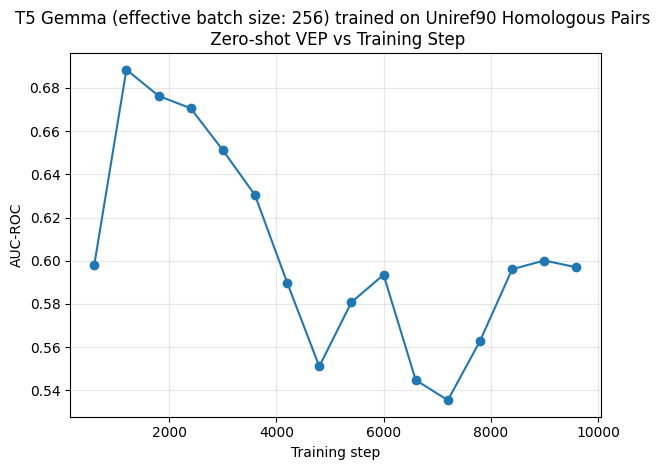

In [1]:
import matplotlib.pyplot as plt

auc_roc = {
    "600":0.5980351745736494, 
    "1200":0.688444796092619, 
    "1800":0.6763199707125005,
    "2400":0.6705564691049782,
    "3000":0.6511683988289553,
    "3600":0.6303775921434881,
    "4200":0.5898707215564856,
    "4800":0.551087956647428, 
    "5400":0.5807938823325738,
    "6000":0.5935137716130717, 
    "6600":0.5447643061826358,
    "7200":0.5354546610367745,
    "7800":0.56284729430975,
    "8400":0.5960752394700923, 
    "9000":0.6001126155029131, 
    "9600":0.5969622057476387
}

# sort by step (convert keys to int so sorting is numeric)
steps = sorted(int(k) for k in auc_roc.keys())
aucs  = [auc_roc[str(s)] for s in steps]

plt.figure()
plt.plot(steps, aucs, marker="o")
plt.xlabel("Training step")
plt.ylabel("AUC-ROC")
plt.title("T5 Gemma (effective batch size: 256) trained on Uniref90 Homologous Pairs \n Zero-shot VEP vs Training Step")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
TSV = "/gpfs/data/brandeslab/Data/uniref/uniref90_cluster_members_ge2_bk_test.tsv"

hist = {}
n = 0
total = 0
mn = 10**18
mx = 0

def bin_label(m: int) -> str:
    if m == 2:
        return "2"
    lo = 2 ** (m.bit_length() - 1)
    hi = 2 ** (m.bit_length()) - 1
    lo = max(lo, 3)
    return f"{lo}-{hi}"

with open(TSV, "r") as f:
    header = next(f)  # skip header
    for line in f:
        # split only first 2 tabs: cluster_id, member_count, (rest ignored)
        parts = line.rstrip("\n").split("\t", 2)
        if len(parts) < 2:
            continue
        m = int(parts[1])
        if m < 2:
            continue

        n += 1
        total += m
        mn = min(mn, m)
        mx = max(mx, m)

        b = bin_label(m)
        hist[b] = hist.get(b, 0) + 1

print(f"clusters (m>=2): {n:,}")
print(f"min: {mn}, max: {mx}, mean: {total/n:.3f}")

clusters (m>=2): 53,506,765
min: 2, max: 26930, mean: 6.188


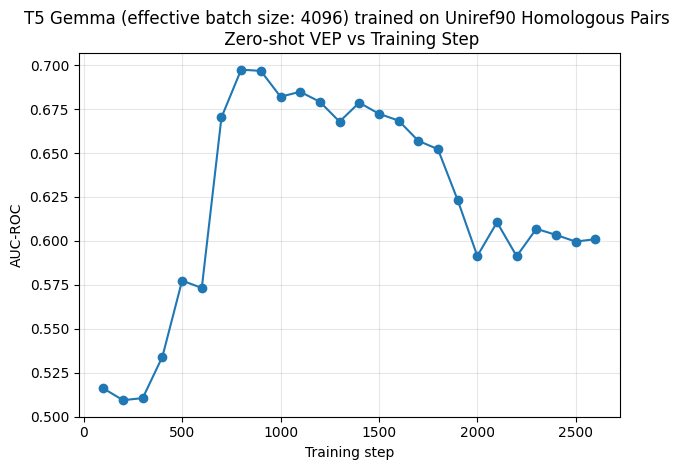

In [1]:
import matplotlib.pyplot as plt

auc_roc = {
    "100":0.5160, 
    "200":0.5093, 
    "300":0.5105,
    "400":0.5341,
    "500":0.5774,
    "600":0.5732,
    "700":0.6703,
    "800":0.6975, 
    "900":0.6968,
    "1000":0.6821, 
    "1100":0.6849,
    "1200":0.6792,
    "1300":0.6679,
    "1400":0.6787, 
    "1500":0.6724, 
    "1600":0.6685, 
    "1700":0.6570, 
    "1800":0.6522, 
    "1900":0.6233, 
    "2000":0.5914, 
    "2100":0.6106, 
    "2200":0.5913, 
    "2300":0.6069, 
    "2400":0.6034, 
    "2500":0.5996, 
    "2600":0.6010
}

# sort by step (convert keys to int so sorting is numeric)
steps = sorted(int(k) for k in auc_roc.keys())
aucs  = [auc_roc[str(s)] for s in steps]

plt.figure()
plt.plot(steps, aucs, marker="o")
plt.xlabel("Training step")
plt.ylabel("AUC-ROC")
plt.title("T5 Gemma (effective batch size: 4096) trained on Uniref90 Homologous Pairs \n Zero-shot VEP vs Training Step")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

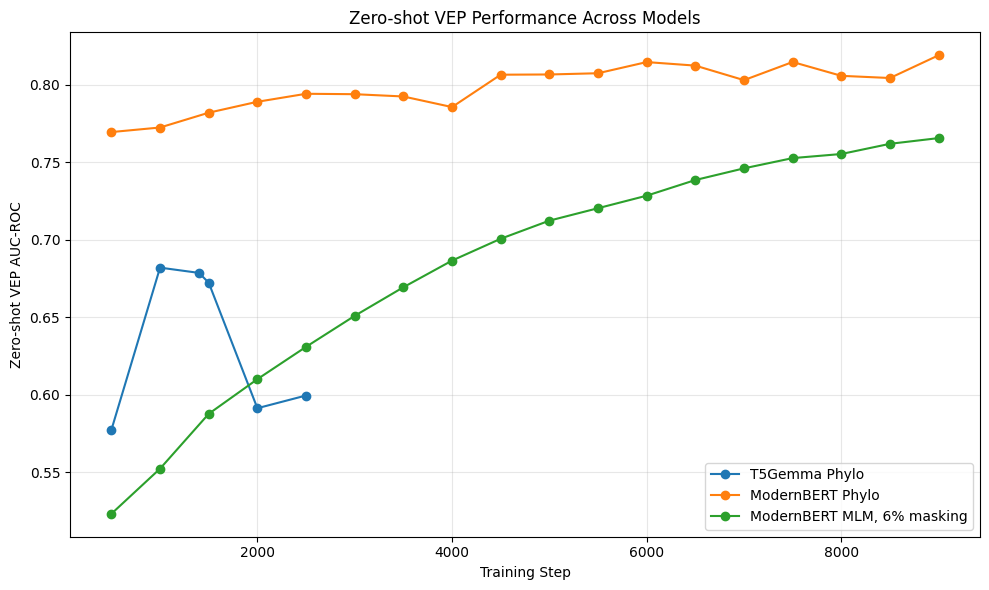

In [3]:
t5_gemma_auc_roc = {
    "500":0.5774,
    "1000":0.6821, 
    "1400":0.6787, 
    "1500": 0.6724, 
    "2000": 0.5914, 
    "2500":0.5996
}


modernBERT_phylo_auc_roc = {
    "500":0.76957,
    "1000":0.77251,
    "1500":0.78206,
    "2000":0.78911, 
    "2500":0.79427,
    "3000":0.794,
    "3500":0.79253,
    "4000":0.78569, 
    "4500":0.80658,
    "5000":0.80672,
    "5500":0.80752,
    "6000":0.81472,
    "6500":0.81244,
    "7000":0.80307,
    "7500":0.81477, 
    "8000":0.80585, 
    "8500":0.80444, 
    "9000":0.81912
}   

modernBERT_mlm_6_auc_roc = {
    "500":0.52328,
    "1000":0.5524,
    "1500":0.58777,
    "2000":0.61014, 
    "2500":0.63099,
    "3000":0.651,
    "3500":0.66944,
    "4000":0.68664, 
    "4500":0.70073,
    "5000":0.71241,
    "5500":0.72044,
    "6000":0.72852,
    "6500":0.73862,
    "7000":0.74616,
    "7500":0.75277, 
    "8000":0.75541, 
    "8500":0.76199, 
    "9000":0.76568
}  


def sort_xy(d):
    x = sorted(int(k) for k in d.keys())
    y = [d[str(step)] for step in x]
    return x, y

x1, y1 = sort_xy(t5_gemma_auc_roc)
x2, y2 = sort_xy(modernBERT_phylo_auc_roc)
x3, y3 = sort_xy(modernBERT_mlm_6_auc_roc)

plt.figure(figsize=(10, 6))
plt.plot(x1, y1, marker='o', label='T5Gemma Phylo')
plt.plot(x2, y2, marker='o', label='ModernBERT Phylo')
plt.plot(x3, y3, marker='o', label='ModernBERT MLM, 6% masking')

plt.xlabel("Training Step")
plt.ylabel("Zero-shot VEP AUC-ROC")
plt.title("Zero-shot VEP Performance Across Models")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




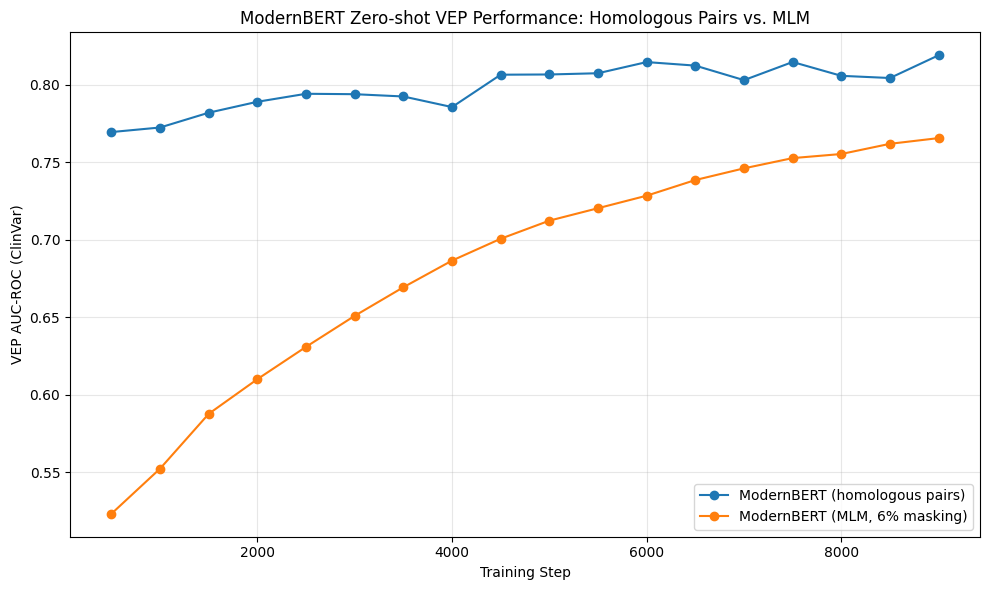

In [6]:
import matplotlib.pyplot as plt

modernBERT_phylo_auc_roc = {
    "500":0.76957,
    "1000":0.77251,
    "1500":0.78206,
    "2000":0.78911, 
    "2500":0.79427,
    "3000":0.794,
    "3500":0.79253,
    "4000":0.78569, 
    "4500":0.80658,
    "5000":0.80672,
    "5500":0.80752,
    "6000":0.81472,
    "6500":0.81244,
    "7000":0.80307,
    "7500":0.81477, 
    "8000":0.80585, 
    "8500":0.80444, 
    "9000":0.81912
}   

modernBERT_mlm_6_auc_roc = {
    "500":0.52328,
    "1000":0.5524,
    "1500":0.58777,
    "2000":0.61014, 
    "2500":0.63099,
    "3000":0.651,
    "3500":0.66944,
    "4000":0.68664, 
    "4500":0.70073,
    "5000":0.71241,
    "5500":0.72044,
    "6000":0.72852,
    "6500":0.73862,
    "7000":0.74616,
    "7500":0.75277, 
    "8000":0.75541, 
    "8500":0.76199, 
    "9000":0.76568
}  


def sort_xy(d):
    x = sorted(int(k) for k in d.keys())
    y = [d[str(step)] for step in x]
    return x, y

x1, y1 = sort_xy(modernBERT_phylo_auc_roc)
x2, y2 = sort_xy(modernBERT_mlm_6_auc_roc)

plt.figure(figsize=(10, 6))
plt.plot(x1, y1, marker='o', label='ModernBERT (homologous pairs)')
plt.plot(x2, y2, marker='o', label='ModernBERT (MLM, 6% masking)')

plt.xlabel("Training Step")
plt.ylabel("VEP AUC-ROC (ClinVar)")
plt.title("ModernBERT Zero-shot VEP Performance: Homologous Pairs vs. MLM")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




Saved plot to vep_auc_comparison.png


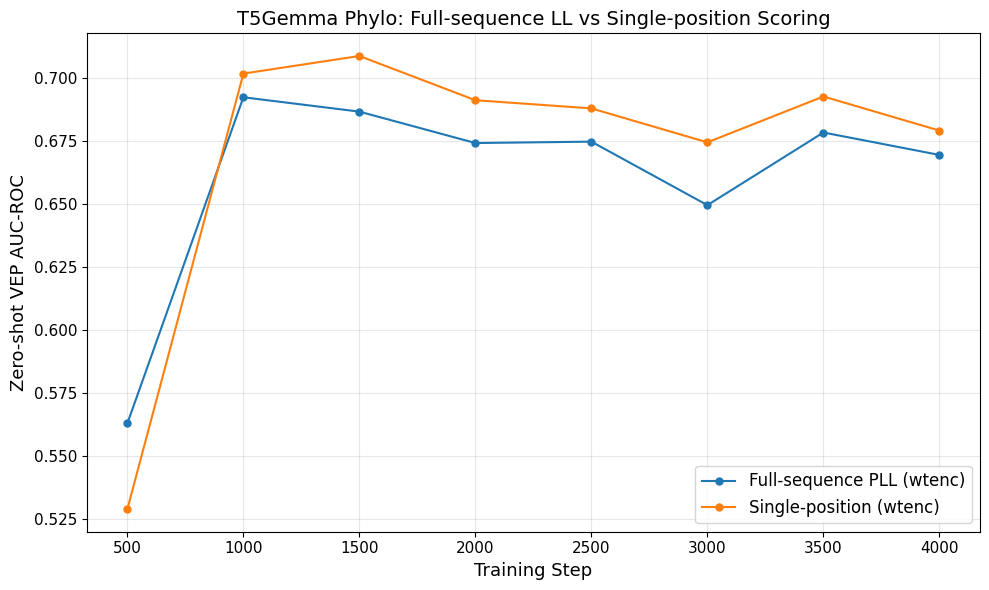

In [3]:
#!/usr/bin/env python3
"""
Plot zero-shot VEP AUC-ROC for two scoring modes on the same axes.

Usage:
    python plot_vep_comparison.py
"""

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIG ---
wtenc_dir = "/gpfs/data/brandeslab/User/as12267/T5Gemma_97M_phylo_bs_4096_arrow_fasta_file_zero_shot_vep_full_seq_LL_wtenc"
singlepos_dir = "/gpfs/data/brandeslab/User/as12267/T5Gemma_97M_phylo_bs_4096_arrow_fasta_file_zero_shot_vep_singlepos_wtenc"
out_path = "vep_auc_comparison.png"


def load_results(directory: str, auc_col: str) -> pd.DataFrame:
    """Read all CSVs in a directory, extract step from checkpoint_dir and the relevant AUC column."""
    csvs = sorted(glob.glob(os.path.join(directory, "*.csv")))
    if not csvs:
        raise FileNotFoundError(f"No CSV files found in {directory}")

    rows = []
    for f in csvs:
        df = pd.read_csv(f)
        for _, row in df.iterrows():
            # Extract step from checkpoint_dir, e.g. "checkpoint-1000" -> 1000
            ckpt_dir = str(row["checkpoint_dir"])
            step = int(ckpt_dir.split("-")[-1])
            auc = row.get(auc_col)
            if pd.isna(auc) or auc == "":
                continue
            rows.append({"step": step, "auc": float(auc)})

    result = pd.DataFrame(rows).sort_values("step")
    return result


# --- Load data ---
df_wtenc = load_results(wtenc_dir, auc_col="auc_pll_wtenc")
df_singlepos = load_results(singlepos_dir, auc_col="auc_pll_singlepos")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_wtenc["step"], df_wtenc["auc"], marker="o", markersize=5,
        label="Full-sequence PLL (wtenc)", color="tab:blue")
ax.plot(df_singlepos["step"], df_singlepos["auc"], marker="o", markersize=5,
        label="Single-position (wtenc)", color="tab:orange")

ax.set_xlabel("Training Step", fontsize=13)
ax.set_ylabel("Zero-shot VEP AUC-ROC", fontsize=13)
ax.set_title("T5Gemma Phylo: Full-sequence LL vs Single-position Scoring", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig(out_path, dpi=150)
print(f"Saved plot to {out_path}")
plt.show()

In [2]:
import lmdb

lmdb_path = "/gpfs/data/brandeslab/Data/uniref/uniref100_merged.lmdb"

env = lmdb.open(
    lmdb_path,
    readonly=True,
    lock=False,
    subdir=True,   # or just omit this, since True is the default
)

with env.begin() as txn:
    rec = "UniRef100_UPI00164F0495"
    val = txn.get(rec.encode("utf-8"))

    if val is None:
        print("Key not found")
    else:
        print(val.decode("utf-8"))

# UniRef100_UPI00164F0495

MNVKQKVLTLIKKSQLENNQYLSTTDLAEKLGLKRNTVSHYLNQLVKENELIKINTRPAVFIFKKIAEKKSGCVLDNEYGSVKELQKKYRDEDVFNNVIGHDKSLYSQIKKIKAAASYPGSLPILITGQTGTGKSYIARKYFEYCVAENYISKEGKFVSFNCAEYADNPELLTGTLFGYVKGAFTGADSNHLGLFDEADGGMLFLDEVHRLDAKGQEKLFSYLDNGSISALGDAGNKKKVNVRLICATTEDIQSSFLETFIRRIPVQISMPPLKERTQNEIRALIIYFYIQHAQKINKSFKINSQVFLTLSNVNYQNNIGQLKNDILLSVASALEKDINSKIISIKLADLPQDILPSTLAENNNSVKGSADLNIKPTSKTTDFIENKNSTNYINKAIQKIYLLYQKEDFLQFRSKAFDVVNSLCDYLIFKKDDLNIGELPLNLIKNTLNQEVGYLKNDFYNDFNGNIIVAISYYFYFRQENHWAISSKESQLIREIIAKLNEVTYVKQIVQVILDTINKTLNLYTDEVDRMFLTIYLESIKRSTNSDLIHCILLAHGYSTASSIADTVNKIIGEPLLDSFDMPIDIKPEDIAQKVANYIRVRHVTKGIILMADMGSLEKIPELIKTEINFPIVIFNNVSTQLALFAAEYIKKKKPLSAMAKDLNQVIHNDYRIIYPKMIKQNVIIVCCTTGIGTAEKIKTMIKDSLPNKTKIMVKAYSYDSLKIEDQENTLKRKYNILTIIGTVNPGYEKIPYISIDQLVNGSKLTTLKDSLQGILSKQDLYKFNDSILKNFSIERVINSLTILDTKAVIRNISFCLEKMNNYLNKRLSNQTTMALYVHISCMIERIIRNQSLENSPRNFTDSKEKEKGIETIKLALHPLEEIYNIRIPKTELKYIYELVFNYDR


In [6]:
from torch.utils.data import Dataset
from datasets import load_dataset, load_from_disk
import random 

class Uniref90ArrowDatasetForLMDB(Dataset):
    """
    Map-style dataset backed by a HuggingFace dataset saved via save_to_disk().
    Each row is a UniRef90 cluster with:
      - "cluster_id": str
      - "member_ids": List[str]  (already prefixed with 'Uniref100_')
    Sequences are fetched on-demand from an LMDB (key=member_id, value=sequence bytes).
    """
    
    def __init__(self, dataset_path: str, training_type: str, lmdb_path: str):
        super().__init__()
        self.training_type = training_type
        self.dataset = load_from_disk(dataset_path)
        self.lmdb_path = lmdb_path
        self._env = None 
    
    def _get_env(self):
        if self._env is None:
            self._env = lmdb.open(
                self.lmdb_path, 
                readonly=True, 
                lock=False, 
                subdir=True)
        return self._env

    def __len__(self):
        return len(self.dataset)

    @staticmethod
    def _fetch_seq(txn, member_id:str) -> str:
        v = txn.get(member_id.encode('utf-8'))
        if v is None:
            raise KeyError(f"Sequence ID {member_id} not found in LMDB")
        return v.decode("ascii", errors="strict")
    
    def __getitem__(self, idx):
        """
        Sample a random cluster globally 
        Sample two distinct member_ids from that cluster
        Fetch sequences from LMDB
        Returns data in the format expected by PhyloCollator:
        - MLM: single string
        - phylo_encoder_only: (a1, a2, pid) tuple
        - phylo_encoder_decoder: (s1, s2) tuple
        """
        # Ignore idx and sample a random cluster globally
        ridx = random.randrange(len(self.dataset))
        ex = self.dataset[ridx]
        member_ids = ex["member_ids"]
        if not member_ids or len(member_ids) < 2:
            # Skip this example by trying the next one
            return self.__getitem__(idx)
        
        m1, m2 = random.sample(member_ids, 2)

        env = self._get_env()
        with env.begin(write=False) as txn:
            try:
                s1 = self._fetch_seq(txn, m1)
                s2 = self._fetch_seq(txn, m2)
            except KeyError:
                # Skip this example by trying the next one
                return self.__getitem__(idx)
        
        if self.training_type == "MLM":
            return s1 if random.random() < 0.5 else s2
            
        elif self.training_type == "phylo_encoder_only":
            a1, a2 = align_pair(s1, s2)
            if len(a1) != len(a2):
                # Skip this example by trying the next one
                return self.__getitem__(idx)
            pid = percent_identity(a1, a2)
            return (a1, a2, pid)
            
        elif self.training_type == "phylo_encoder_decoder":
            return (s1, s2)

In [7]:
train_file = "/gpfs/data/brandeslab/Data/uniref/uniref90_clusters_arrow/train"
lmdb_file = "/gpfs/data/brandeslab/Data/uniref/uniref100_merged.lmdb"
train_ds = Uniref90ArrowDatasetForLMDB(dataset_path=train_file,
                                  training_type="phylo_encoder_decoder", 
                                  lmdb_path=lmdb_file)
print(train_ds)

In [8]:
# 1. Check the length
print(f"Dataset length: {len(train_ds)}")

# 2. Get a single example
example = train_ds[0]
print(f"\nFirst example type: {type(example)}")
print(f"First example: {example}")

# 3. Check multiple examples
print("\n--- First 3 examples ---")
for i in range(3):
    ex = train_ds[i]
    if isinstance(ex, tuple):
        s1, s2 = ex
        print(f"Example {i}: len(s1)={len(s1)}, len(s2)={len(s2)}")
        print(f"  s1[:50]: {s1[:50]}")
        print(f"  s2[:50]: {s2[:50]}")
    else:
        print(f"Example {i}: {ex[:50]}...")

# 4. Check the underlying HF dataset
print(f"\nUnderlying dataset info:")
print(f"  Type: {type(train_ds.dataset)}")
print(f"  Num rows: {train_ds.dataset.num_rows}")
print(f"  Column names: {train_ds.dataset.column_names}")
print(f"  Features: {train_ds.dataset.features}")

Dataset length: 53405637

First example type: <class 'tuple'>
First example: ('MSDTTAHSGLDGLDTPFLAVDLAVMDRNIERLAGRLRGTGIRLRPHAKSHKCIEIARRQIDSGAIGLTVATVGEAEVFAEAGFIDLFIAYPLWVTAQKAHRLRQVASRAALRVAVDSAAGAQQLAEHLGDLPITVVIEVDSGHHRTGVAPNQAGPVAAAARSAGLNVVGIFTFPGHGYTPGHRAEVAAQESHALDTAAASLRAQGIDPSVRSGGSTPTVGAADDTVLTEVRPGVYPFNDAQQLELDVCTLDDIALSAVTTVVHARGRTAVVDAGSKILGADRPGWATGFGRVIDEPDARIVALSEHHATIEFPSAAPPPGTRLRVAPNHLCNAVNLVDSLVIDAADGVRHWAVAARGANT', 'MSDTTAHSGLDGLDTPFLAVDLAVMDRNIERLAGRLRGTGIRLRPHAKSHKCIEIARRQIDSGAIGLTVATIGEAEVFAEAGFIDLFIAYPLWVTAQKARRLRQVASRAALRVAVDSAAGAQQLAEHLGDLPITVVIEVDSGHHRTGVAPDEAGPVAAAARSAGLNVVGIFTFPGHGYTPGHRAEVAAQESHALDTAAAGLRAQGIDPSVRSGGSTPTVGAADDTVLTEVRPGVYPFNDAQQFELDVCTLDDIALSAVTTVVHARGRTAVVDAGSKILGADRPGWATGFGRVIDEPDARIVALSEHHATIEFPGAAPPPGTRLRVAPNHLCNAVNLVDSLVIDAADGVRHWAVAARGANT')

--- First 3 examples ---
Example 0: len(s1)=206, len(s2)=176
  s1[:50]: MTDSNFIGMLPDIEESRRIFQAAAILDAILMPEWEYRYYSYNAHWDENEQ
  s2[:50]: MPEWEYRYYSYNAHWDENEQMASIRDGEGDHYFALFQPNGLIVKGFDQRF
Example 